In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
class MachineLearningModel:
    def __init__(self, x_train, y_train, x_test, y_test):
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.model = GradientBoostingRegressor(
            random_state=42,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9
        )
        
        self.model.fit(self.x_train, self.y_train)
        
        # --- VALUTAZIONE ---
        self.y_pred = self.model.predict(self.x_test)
        
        print("MAE test:", mean_absolute_error(self.y_test, self.y_pred))
        print("RMSE test:", np.sqrt(mean_squared_error(self.y_test, self.y_pred)))
        print("R2 test:", r2_score(self.y_test, self.y_pred))
        # --- FEATURE IMPORTANCE ---
        self.importances = pd.DataFrame({
            "feature": self.x_train.columns,
            "importance": self.model.feature_importances_
        }).sort_values(by="importance", ascending=False)
        
        print(self.importances)

    def predict(self, df_future):
        self.df_future = df_future
        # Allineamento colonne
        self.missing_cols = set(self.x_train.columns) - set(self.df_future.columns)
        for col in self.missing_cols:
            self.df_future[col] = 0
        
        self.df_future = self.df_future[self.x_train.columns]
        
        # Predizione
        self.df_future["PREDICTED_REVENUE"] = self.model.predict(self.df_future)

        return self.df_future

In [3]:
def prepare_features(df):
    df = df.copy()

    # 0. RIMOZIONE COLONNE STRETTAMENTE CORRELATE
    df = df.drop(columns=["ID_ORDER_NUM", "VAL_COST"], errors="ignore")

    # 1. Rimozione colonne descrittive
    desc_cols = [c for c in df.columns if c.startswith("DESC_")]
    df = df.drop(columns=desc_cols, errors="ignore")

    # 2. Encoding categorico compatto
    categorical_cols = [
        "ID_COMPANY", "IDS_CUSTOMER", "IDS_ITEM",
        "ID_BUSINESS_LINE", "ID_COUNTRY", "ID_AREA_MANAGER"
    ]

    enc = LabelEncoder()
    for col in categorical_cols:
        df[col] = enc.fit_transform(df[col])

    # 3. Feature temporali
    df["ID_ORDER_DATE"] = pd.to_datetime(df["ID_ORDER_DATE"])
    df["ANNO"] = df["ID_ORDER_DATE"].dt.year
    df["MESE"] = df["ID_ORDER_DATE"].dt.month
    df["GIORNO"] = df["ID_ORDER_DATE"].dt.day
    df["GIORNO_SETTIMANA"] = df["ID_ORDER_DATE"].dt.weekday
    df["WEEKEND"] = df["GIORNO_SETTIMANA"].isin([5,6]).astype(int)

    df["GIORNO_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.dayofyear / 365)
    df["GIORNO_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.dayofyear / 365)
    
    # 4. ordinamento
    df = df.sort_values("ID_ORDER_DATE")


    # 5. Rimozione date originali
    df = df.drop(columns=["ID_ORDER_DATE", "ID_INVOICE_DATE"], errors="ignore")
    
    return df

In [4]:
def make_forecast(start_date, end_date, df_old):
    """
    Genera forecast solo per le combinazioni cliente-item esistenti nello storico.
    e applica le feature temporali tramite prepare_features().
    NON allinea le colonne con il train.
    """

    # 1. GENERO IL CALENDARIO FUTURO
    future_dates = pd.date_range(start=start_date, end=end_date, freq="D")
    df_future = pd.DataFrame({"ID_ORDER_DATE": future_dates})

    # 2. Estraggo combinazioni reali cliente-item-company-line-area-country
    dims = df_old[[
        "ID_COMPANY",
        "IDS_ITEM",
        "ID_BUSINESS_LINE",
        "IDS_CUSTOMER",
        "ID_AREA_MANAGER",
        "ID_COUNTRY"
    ]].drop_duplicates()

    df_future = df_future.merge(dims, how="cross")

    # 3. APPLICO LE FEATURE (prepare_features)
    df_future = prepare_features(df_future)

    # 4. RESTITUISCO IL DATAFRAME FUTURO
    return df_future

In [5]:
def plot_trend(df_actual, df_forecast):
    """
    Plotta i dati storici (VAL_REVENUES) e il forecast (PREDICTED_REVENUE) insieme
    """
    df_actual = df_actual.copy()
    df_forecast = df_forecast.copy()

    # Aggiungi anno/mese a df_actual se non presenti
    if "ANNO" not in df_actual.columns:
        df_actual["ANNO"] = 2025  # placeholder

    # Calcola medie mensili
    trend_actual = df_actual.groupby(["ANNO", "MESE"])["VAL_REVENUES"].mean().reset_index()
    trend_forecast = df_forecast.groupby(["ANNO", "MESE"])["PREDICTED_REVENUE"].mean().reset_index()

    years = sorted(set(list(trend_actual["ANNO"].unique()) + list(trend_forecast["ANNO"].unique())))
    n_years = len(years)
    
    fig, axes = plt.subplots(1, n_years, figsize=(7*n_years, 5), sharey=True)
    
    if n_years == 1:
        axes = [axes]
    
    colors_actual = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for idx, anno in enumerate(years):
        ax = axes[idx]
        
        # Dati storici
        subset_actual = trend_actual[trend_actual["ANNO"] == anno]
        if len(subset_actual) > 0:
            ax.plot(
                subset_actual["MESE"],
                subset_actual["VAL_REVENUES"],
                marker="o",
                linewidth=2.5,
                markersize=8,
                label=f"Storico {anno}",
                alpha=0.9,
                color=colors_actual[idx % len(colors_actual)]
            )
        
        # Forecast
        subset_forecast = trend_forecast[trend_forecast["ANNO"] == anno]
        if len(subset_forecast) > 0:
            ax.plot(
                subset_forecast["MESE"],
                subset_forecast["PREDICTED_REVENUE"],
                marker="s",
                linewidth=2.5,
                markersize=8,
                label=f"Forecast {anno}",
                alpha=0.9,
                color=colors_actual[idx % len(colors_actual)],
                linestyle='--'
            )
        
        ax.set_xlim(0.5, 12.5)
        ax.set_ylim(25000, 45000)
        ax.set_xlabel("Mese", fontsize=11, fontweight='bold')
        ax.set_ylabel("Revenue Media (€)", fontsize=11, fontweight='bold') if idx == 0 else None
        ax.set_title(f"Anno {anno}", fontsize=12, fontweight='bold')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels([f"{i}" for i in range(1, 13)])
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=10)
    
    fig.suptitle("Confronto Dati Storici vs Forecast", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("trend_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

In [6]:
def train_test_split(df):
    split_idx = int(len(df) * 0.9)
    
    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:]
    
    x_train = train.drop(columns=["VAL_REVENUES"])
    y_train = train["VAL_REVENUES"]
    
    x_test = test.drop(columns=["VAL_REVENUES"])
    y_test = test["VAL_REVENUES"]

    return x_train, y_train, x_test, y_test

In [7]:
def main():
    df = pd.read_csv("SALES_OLAP.csv")
    df_ml = prepare_features(df)
    x_train, y_train, x_test, y_test = train_test_split(df_ml)
    ml = MachineLearningModel(x_train, y_train, x_test, y_test)

    df_future = make_forecast(
        start_date="2026-03-01",
        end_date="2027-03-01",
        df_old=df
    )

    df_future = ml.predict(df_future)
    df_future.to_csv("SALES_FORECAST.csv",index=False)
    plot_trend(df_ml, df_future)

MAE test: 3786.4071897145805
RMSE test: 5065.232450339942
R2 test: 0.5185681343814295
             feature  importance
5    ID_AREA_MANAGER    0.537752
2           IDS_ITEM    0.205079
1       IDS_CUSTOMER    0.088717
12        GIORNO_COS    0.056013
8             GIORNO    0.044032
3   ID_BUSINESS_LINE    0.026404
11        GIORNO_SIN    0.024013
7               MESE    0.008386
4         ID_COUNTRY    0.007964
9   GIORNO_SETTIMANA    0.000857
0         ID_COMPANY    0.000719
6               ANNO    0.000067
10           WEEKEND    0.000000


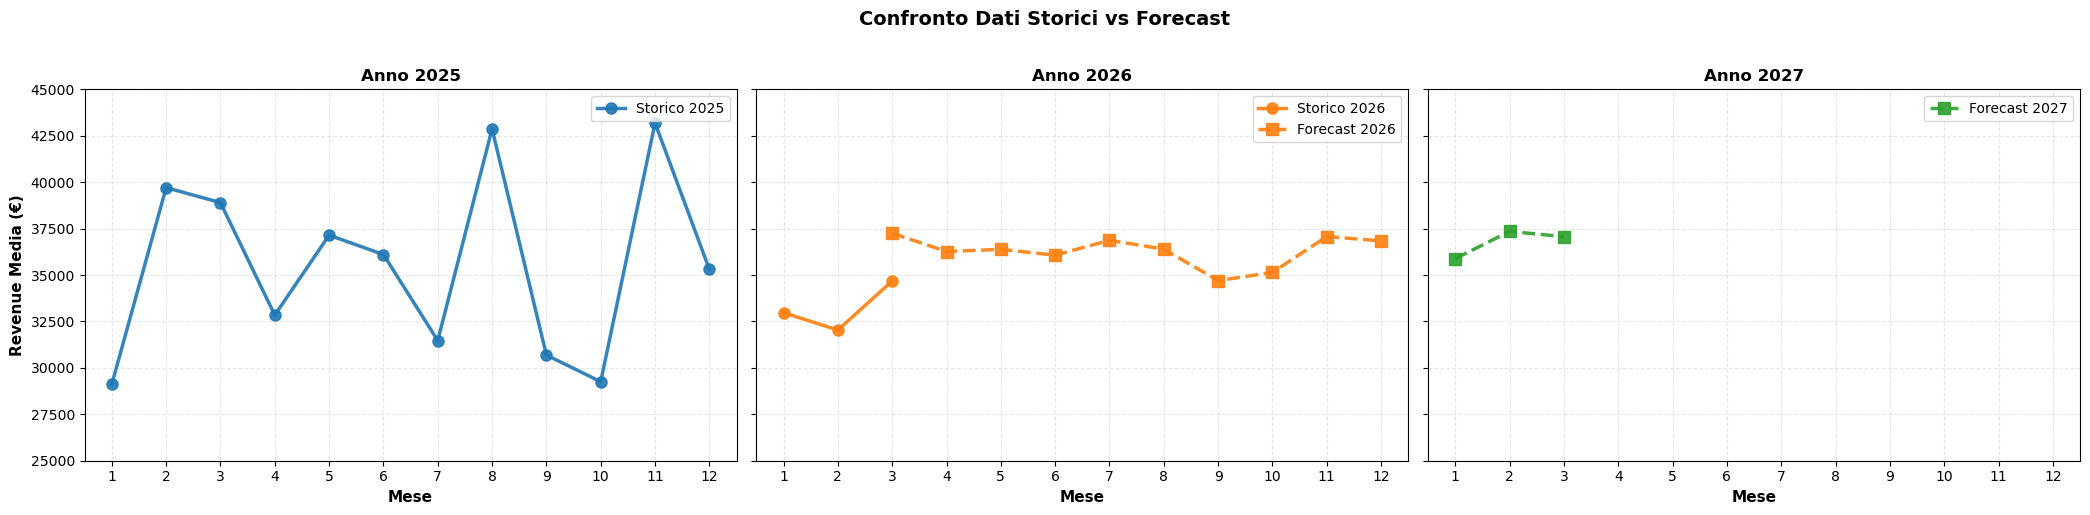

In [8]:
if __name__ == "__main__":
    app = main()